# Deep Learning Applications: Laboratory #1

In this first laboratory we will work relatively simple architectures to get a feel for working with Deep Models. This notebook is designed to work with PyTorch, but as I said in the introductory lecture: please feel free to use and experiment with whatever tools you like.

**Important Notes**:
1. Be sure to **document** all of your decisions, as well as your intermediate and final results. Make sure your conclusions and analyses are clearly presented. Don't make us dig into your code or walls of printed results to try to draw conclusions from your code.
2. If you use code from someone else (e.g. Github, Stack Overflow, ChatGPT, etc) you **must be transparent about it**. Document your sources and explain how you adapted any partial solutions to creat **your** solution.



## Exercise 1: Warming Up
In this series of exercises I want you to try to duplicate (on a small scale) the results of the ResNet paper:

> [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, CVPR 2016.

We will do this in steps using a Multilayer Perceptron on MNIST.

Recall that the main message of the ResNet paper is that **deeper** networks do not **guarantee** more reduction in training loss (or in validation accuracy). Below you will incrementally build a sequence of experiments to verify this for an MLP. A few guidelines:

+ I have provided some **starter** code at the beginning. **NONE** of this code should survive in your solutions. Not only is it **very** badly written, it is also written in my functional style that also obfuscates what it's doing (in part to **discourage** your reuse!). It's just to get you *started*.
+ These exercises ask you to compare **multiple** training runs, so it is **really** important that you factor this into your **pipeline**. Using [Tensorboard](https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) is a **very** good idea -- or, even better [Weights and Biases](https://wandb.ai/site).
+ You may work and submit your solutions in **groups of at most two**. Share your ideas with everyone, but the solutions you submit *must be your own*.

First some boilerplate to get you started, then on to the actual exercises!

### Preface: Some code to get you started

What follows is some **very simple** code for training an MLP on MNIST. The point of this code is to get you up and running (and to verify that your Python environment has all needed dependencies).

**Note**: As you read through my code and execute it, this would be a good time to think about *abstracting* **your** model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

In [ ]:
# Start with some standard imports.
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import torch
from torchvision.datasets import MNIST
from torch.utils.data import Subset
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

#### Data preparation

Here is some basic dataset loading, validation splitting code to get you started working with MNIST.

In [1]:
# Standard MNIST transform.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST train and test.
ds_train = MNIST(root='./data', train=True, download=True, transform=transform)
ds_test = MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train and validation.
val_size = 5000
I = np.random.permutation(len(ds_train))
ds_val = Subset(ds_train, I[:val_size])
ds_train = Subset(ds_train, I[val_size:])

NameError: name 'transforms' is not defined

#### Boilerplate training and evaluation code

This is some **very** rough training, evaluation, and plotting code. Again, just to get you started. I will be *very* disappointed if any of this code makes it into your final submission.

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# Function to train a model for a single epoch over the data loader.
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Function to evaluate model over all samples in the data loader.
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
        xs = xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())
        
    # Return accuracy score and classification report.
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Simple function to plot the loss curve and validation accuracy.
def plot_validation_curves(losses_and_accs):
    losses = [x for (x, _) in losses_and_accs]
    accs = [x for (_, x) in losses_and_accs]
    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Average Training Loss per Epoch')
    plt.subplot(1, 2, 2)
    plt.plot(accs)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title(f'Best Accuracy = {np.max(accs)} @ epoch {np.argmax(accs)}')

#### A basic, parameterized MLP

This is a very basic implementation of a Multilayer Perceptron. Don't waste too much time trying to figure out how it works -- the important detail is that it allows you to pass in a list of input, hidden layer, and output *widths*. **Your** implementation should also support this for the exercises to come.

In [ ]:
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(nin, nout) for (nin, nout) in zip(layer_sizes[:-1], layer_sizes[1:])])
    
    def forward(self, x):
        return reduce(lambda f, g: lambda x: g(F.relu(f(x))), self.layers, lambda x: x.flatten(1))(x)

#### A *very* minimal training pipeline.

Here is some basic training and evaluation code to get you started.

**Important**: I cannot stress enough that this is a **terrible** example of how to implement a training pipeline. You can do better!

In [ ]:
# Training hyperparameters.
device = 'cuda' if torch.cuda.is_available else 'cpu'
epochs = 100
lr = 0.0001
batch_size = 128

# Architecture hyperparameters.
input_size = 28*28
width = 16
depth = 2

# Dataloaders.
dl_train = torch.utils.data.DataLoader(ds_train, batch_size, shuffle=True, num_workers=4)
dl_val   = torch.utils.data.DataLoader(ds_val, batch_size, num_workers=4)
dl_test  = torch.utils.data.DataLoader(ds_test, batch_size, shuffle=True, num_workers=4)

# Instantiate model and optimizer.
model_mlp = MLP([input_size] + [width]*depth + [10]).to(device)
opt = torch.optim.Adam(params=model_mlp.parameters(), lr=lr)

# Training loop.
losses_and_accs = []
for epoch in range(epochs):
    loss = train_epoch(model_mlp, dl_train, opt, epoch, device=device)
    (val_acc, _) = evaluate_model(model_mlp, dl_val, device=device)
    losses_and_accs.append((loss, val_acc))

# And finally plot the curves.
plot_validation_curves(losses_and_accs)
print(f'Accuracy report on TEST:\n {evaluate_model(model_mlp, dl_test, device=device)[1]}')

### Shared setup

Imports, data loading and the training pipeline shared by all the exercises below. Every run is logged to the same W&B project (`dla-lab1`), so runs from different exercises can be compared directly.

In [1]:
# Shared setup: imports, data loading and the training pipeline used by all exercises.

import copy
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm
import wandb

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Absolute paths: the IDE starts Jupyter in a random /tmp folder on the server,
# so relative paths like "./data" would point to a new, empty folder every session.
DATA_DIR = os.path.expanduser("~/data")
CHECKPOINT_DIR = os.path.expanduser("~/checkpoints")


def set_seed(seed=42):
    """Fix every random number generator, so that runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


# ----------------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------------

def split_train_val(train_view, val_view, val_size, seed=42):
    """Randomly (but reproducibly) choose `val_size` training images for validation.

    `train_view` and `val_view` contain the same images with possibly different
    transforms: this way data augmentation (used in later exercises) is applied
    to the training split only, never to the validation split.
    """
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(train_view), generator=generator).tolist()

    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    train_set = Subset(train_view, train_indices)
    val_set = Subset(val_view, val_indices)
    return train_set, val_set


def make_loaders(train_set, val_set, test_set, batch_size, num_workers=4):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size,
                            num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size,
                             num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


def get_mnist_loaders(batch_size=128, val_size=5000):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean and std
    ])
    train_full = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
    test_set = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

    # No augmentation on MNIST, so training and validation use the same transform.
    train_set, val_set = split_train_val(train_full, train_full, val_size)
    return make_loaders(train_set, val_set, test_set, batch_size)


def get_cifar10_loaders(batch_size=128, val_size=5000):
    mean = (0.4914, 0.4822, 0.4465)  # CIFAR-10 per-channel mean and std
    std = (0.2470, 0.2435, 0.2616)

    # Standard CIFAR-10 augmentation (as in the ResNet paper): random shifts and flips.
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # Two views of the same training images: augmented for the training split,
    # clean for the validation split.
    train_view = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
    val_view = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=eval_transform)
    test_set = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=eval_transform)

    train_set, val_set = split_train_val(train_view, val_view, val_size)
    return make_loaders(train_set, val_set, test_set, batch_size)


# ----------------------------------------------------------------------------
# Training and evaluation
# ----------------------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, loss_fn):
    """One pass over the training set. Returns the mean loss and the accuracy (%)."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False, mininterval=1.0):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # loss.item() is the mean over the batch: weight it by the batch size.
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, loss_fn):
    """Mean loss and accuracy (%) on a validation or test set. The model is not updated."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False, mininterval=1.0):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def fit(model, train_loader, val_loader, epochs, lr=1e-3):
    """Train `model` with Adam, logging every epoch to the active W&B run.

    At the end the model is restored to the weights of the epoch with the best
    validation accuracy. Returns the per-epoch metrics as a DataFrame.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    history = []
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)

        metrics = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        wandb.log(metrics)
        history.append(metrics)
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {train_loss:.4f}, acc {train_acc:.2f}% | "
              f"val loss {val_loss:.4f}, acc {val_acc:.2f}%")

        # deepcopy is needed: state_dict() returns references to the live weights,
        # which the next epochs would keep modifying.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    wandb.summary["best_val_acc"] = best_val_acc
    return pd.DataFrame(history)

Using device: cuda


### Exercise 1.1: A baseline MLP

Implement a *simple* Multilayer Perceptron to classify the 10 digits of MNIST (e.g. two *narrow* layers). Use my code above as inspiration, but implement your own training pipeline -- you will need it later. Train this model to convergence, monitoring (at least) the loss and accuracy on the training and validation sets for every epoch. Below I include a basic implementation to get you started -- remember that you should write your *own* pipeline!

**Note**: This would be a good time to think about *abstracting* your model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

**Important**: Given the *many* runs you will need to do, and the need to *compare* performance between them, this would **also** be a great point to study how **Tensorboard** or **Weights and Biases** can be used for performance monitoring.

In [3]:
# Exercise 1.1: A baseline MLP

class MLP(nn.Module):
    """Multilayer Perceptron built from a list of layer widths.

    Example: MLP([784, 128, 128, 10]) has a 784-dimensional input,
    two hidden layers of width 128 and 10 outputs (one per digit).
    """

    def __init__(self, layer_sizes, dropout=0.0):
        super().__init__()
        layers = [nn.Flatten()]  # 28x28 image -> vector of 784 values

        # Hidden layers: Linear -> ReLU -> Dropout
        for i in range(len(layer_sizes) - 2):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # Output layer without activation: CrossEntropyLoss expects raw logits.
        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Hyperparameters
batch_size = 64
epochs = 30
lr = 1e-3
layer_sizes = [28 * 28, 128, 128, 10]

train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()

# Train the same architecture without and with dropout, to compare overfitting.
results = []
for dropout in [0.0, 0.2]:
    set_seed(42)
    model = MLP(layer_sizes, dropout=dropout).to(device)
    print(f"\nMLP {layer_sizes}, dropout={dropout}, {count_params(model):,} parameters")

    wandb.init(
        project="dla-lab1",
        name=f"1.1-mlp-dropout{dropout}",
        config={"exercise": "1.1", "layer_sizes": layer_sizes, "dropout": dropout,
                "batch_size": batch_size, "epochs": epochs, "lr": lr},
    )
    history = fit(model, train_loader, val_loader, epochs=epochs, lr=lr)

    # The model now has the weights of its best validation epoch.
    test_loss, test_acc = evaluate(model, test_loader, loss_fn)
    wandb.summary["test_acc"] = test_acc
    wandb.finish()

    results.append({
        "dropout": dropout,
        "best_val_acc": history["val_acc"].max(),
        "test_acc": test_acc,
    })

pd.DataFrame(results).round(2)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 245kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.14MB/s]



MLP [784, 128, 128, 10], dropout=0.0, 118,282 parameters


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/Accia/.netrc.
wandb: Currently logged in as: franciaccia (franciaccia-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch   1/30 | train loss 0.2723, acc 91.98% | val loss 0.1631, acc 94.92%


Epoch   2/30 | train loss 0.1138, acc 96.51% | val loss 0.1145, acc 96.30%


...

Epoch  28/30 | train loss 0.0394, acc 98.69% | val loss 0.0844, acc 97.82%


Epoch  29/30 | train loss 0.0414, acc 98.73% | val loss 0.0834, acc 97.94%


Epoch  30/30 | train loss 0.0387, acc 98.83% | val loss 0.0890, acc 97.86%


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▅▆▆▇▇▇▇▇▇▇▇██████████████████
train_loss,█▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▆▇▇▆▇█▇▇▇▇▇▇▇▇██████▇▇██
val_loss,█▄▃▃▂▁▁▁▁▂▂▁▂▁▂▁▂▂▂▂▂▁▂▂▂▂▁▂▂▂
best_val_acc,98.04
epoch,30
test_acc,97.89
train_acc,98.82727
train_loss,0.03875
val_acc,97.86


,dropout,best_val_acc,test_acc
0,0.0,98.06,98.00
1,0.2,98.04,97.89


### Exercise 1.2: Adding Residual Connections

Implement a variant of your parameterized MLP network to support **residual** connections. Your network should be defined as a composition of **residual MLP** blocks that have one or more linear layers and add a skip connection from the block input to the output of the final linear layer.

**Compare** the performance (in training/validation loss and test accuracy) of your MLP and ResidualMLP for a range of depths. Verify that deeper networks **with** residual connections are easier to train than a network of the same depth **without** residual connections.

**For extra style points**: See if you can explain by analyzing the gradient magnitudes on a single training batch *why* this is the case. 

In [7]:
# Exercise 1.2: Adding Residual Connections

class MLPBlock(nn.Module):
    """Two linear layers of the same width.

    With `residual=True` the block input is added to the output of the second
    linear layer (skip connection), exactly as in a ResNet basic block.
    Plain and residual blocks have the same number of parameters.
    """

    def __init__(self, width, residual):
        super().__init__()
        self.residual = residual
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)

    def forward(self, x):
        out = torch.relu(self.fc1(x))
        out = self.fc2(out)
        if self.residual:
            out = out + x  # skip connection
        return torch.relu(out)


class DeepMLP(nn.Module):
    """Input layer -> `depth` MLPBlocks -> output layer (2 * depth + 2 linear layers)."""

    def __init__(self, input_size, width, depth, num_classes, residual):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(input_size, width)
        self.blocks = nn.ModuleList()
        for _ in range(depth):
            self.blocks.append(MLPBlock(width, residual))
        self.output_layer = nn.Linear(width, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.input_layer(x))
        for block in self.blocks:
            x = block(x)
        return self.output_layer(x)


# Hyperparameters
batch_size = 128
epochs = 10
lr = 1e-3
width = 128
depths = [1, 4, 8, 16]  # number of blocks -> 4, 10, 18 and 34 linear layers

train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()

# Train a plain and a residual network for every depth, with identical settings.
for depth in depths:
    for residual in [False, True]:
        kind = "residual" if residual else "plain"
        name = f"{kind}-depth{depth}"
        set_seed(42)
        model = DeepMLP(28 * 28, width, depth, 10, residual).to(device)
        print(f"\n{name}: {2 * depth + 2} linear layers, {count_params(model):,} parameters")

        wandb.init(
            project="dla-lab1",
            name=f"1.2-{name}",
            group="1.2-residual-mlp",
            config={"exercise": "1.2", "depth": depth, "residual": residual, "width": width,
                    "batch_size": batch_size, "epochs": epochs, "lr": lr},
        )
        fit(model, train_loader, val_loader, epochs=epochs, lr=lr)

        test_loss, test_acc = evaluate(model, test_loader, loss_fn)
        wandb.summary["test_acc"] = test_acc
        wandb.finish()


plain-depth1: 4 linear layers, 134,794 parameters


Epoch   1/10 | train loss 0.3345, acc 89.94% | val loss 0.1968, acc 93.78%


Epoch   2/10 | train loss 0.1312, acc 96.01% | val loss 0.1209, acc 96.18%


Epoch   3/10 | train loss 0.0906, acc 97.20% | val loss 0.0963, acc 97.08%


Epoch   4/10 | train loss 0.0692, acc 97.85% | val loss 0.0996, acc 97.06%


...

Epoch   7/10 | train loss 0.0391, acc 98.75% | val loss 0.0805, acc 97.86%


Epoch   8/10 | train loss 0.0361, acc 98.84% | val loss 0.0819, acc 97.90%


Epoch   9/10 | train loss 0.0318, acc 98.97% | val loss 0.1047, acc 97.10%


Epoch  10/10 | train loss 0.0288, acc 99.06% | val loss 0.1077, acc 97.14%


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▃▆▆▇▇██▆▆
val_loss,█▅▄▂▂▁▁▁▃▃
best_val_acc,97.9
epoch,10
test_acc,97.73
train_acc,99.06182
train_loss,0.02877
val_acc,97.14


#### Gradient analysis

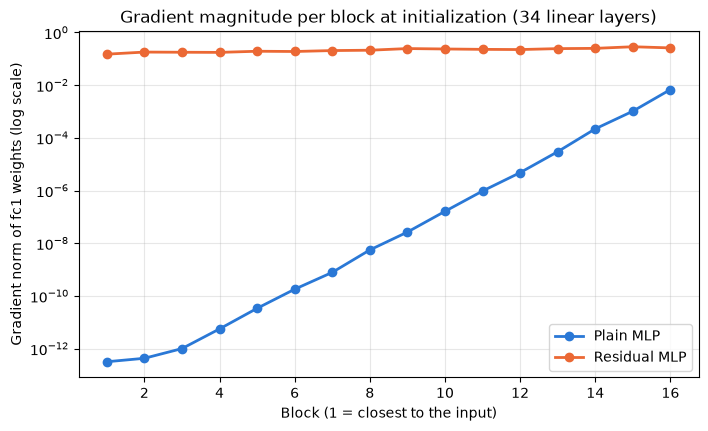

In [9]:
# Why are residual networks easier to train? Look at the gradients.
# For the deepest plain and residual networks, at initialization, we backpropagate
# the loss of a single training batch and measure how large the gradient is in
# every block. Block 1 is the closest to the input, i.e. the farthest from the loss.

def block_gradient_norms(model, images, labels):
    """Norm of the gradient of each block's first linear layer, for one batch."""
    model.zero_grad()
    loss = nn.CrossEntropyLoss()(model(images), labels)
    loss.backward()

    norms = []
    for block in model.blocks:
        norms.append(block.fc1.weight.grad.norm().item())
    return norms


images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

deepest = max(depths)
grad_norms = {}
for residual in [False, True]:
    set_seed(42)
    model = DeepMLP(28 * 28, width, deepest, 10, residual).to(device)
    grad_norms[residual] = block_gradient_norms(model, images, labels)

block_ids = range(1, deepest + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(block_ids, grad_norms[False], marker="o", linewidth=2, color="#2a78d6", label="Plain MLP")
plt.plot(block_ids, grad_norms[True], marker="o", linewidth=2, color="#eb6834", label="Residual MLP")
plt.yscale("log")
plt.xlabel("Block (1 = closest to the input)")
plt.ylabel("Gradient norm of fc1 weights (log scale)")
plt.title(f"Gradient magnitude per block at initialization ({2 * deepest + 2} linear layers)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Exercise 1.3: Rinse and Repeat (but with a CNN)

Repeat the verification you did above, but with **Convolutional** Neural Networks. If you were careful about abstracting your model and training code, this should be a simple exercise. Show that **deeper** CNNs *without* residual connections do not always work better and **even deeper** ones *with* residual connections.

**Hint**: You probably should do this exercise using CIFAR-10, since MNIST is *very* easy (at least up to about 99% accuracy).

**Tip**: Feel free to reuse the ResNet building blocks defined in `torchvision.models.resnet` (e.g. [BasicBlock](https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py#L59) which handles the cascade of 3x3 convolutions, skip connections, and optional downsampling). This is an excellent exercise in code diving. 

**Spoiler**: Depending on the optional exercises you plan to do below, you should think *very* carefully about the architectures of your CNNs here (so you can reuse them!).

In [2]:
# Exercise 1.3: Rinse and Repeat (but with a CNN)
#
# Plain and residual CNNs that differ only in the skip connections, following the
# CIFAR-10 networks of the ResNet paper (Section 4.2): a 3x3 stem convolution,
# three stages of blocks with 16, 32 and 64 channels, global average pooling and
# a linear classifier. With n blocks per stage the network has 6n + 2 layers.
# ConvBlock is modelled on torchvision's BasicBlock (torchvision/models/resnet.py),
# with a flag to switch the skip connection off.

class ConvBlock(nn.Module):
    """Two 3x3 convolutions with BatchNorm (a ResNet basic block).

    With `residual=True` the block input is added to the output. When the block
    halves the resolution or changes the number of channels, the input does not
    have the same shape as the output, so the skip connection uses a 1x1
    convolution to match them.
    """

    def __init__(self, in_channels, out_channels, stride, residual):
        super().__init__()
        self.residual = residual
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Identity()
        if residual and (stride != 1 or in_channels != out_channels):
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.residual:
            out = out + self.shortcut(x)  # skip connection
        return torch.relu(out)


class CifarCNN(nn.Module):
    """Stem -> 3 stages of `blocks_per_stage` ConvBlocks -> global average pooling -> linear."""

    def __init__(self, blocks_per_stage, residual, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
        )

        blocks = []
        in_channels = 16
        for stage, out_channels in enumerate([16, 32, 64]):
            for i in range(blocks_per_stage):
                # The first block of stages 2 and 3 halves the resolution: 32 -> 16 -> 8.
                stride = 2 if (stage > 0 and i == 0) else 1
                blocks.append(ConvBlock(in_channels, out_channels, stride, residual))
                in_channels = out_channels
        self.blocks = nn.Sequential(*blocks)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def feature_maps(self, x):
        """Output of the last block (64 x 8 x 8), before pooling.
        Kept separate so that Exercise 2 can reuse the convolutional features."""
        return self.blocks(self.stem(x))

    def forward(self, x):
        x = self.feature_maps(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


# Hyperparameters
batch_size = 128
epochs = 10
lr = 1e-3
blocks_per_stage = [1, 3, 5, 9]  # -> 8, 20, 32 and 56 layers

train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Train a plain and a residual network for every depth, with identical settings.
for n in blocks_per_stage:
    for residual in [False, True]:
        kind = "residual" if residual else "plain"
        num_layers = 6 * n + 2
        name = f"{kind}-{num_layers}layers"
        set_seed(42)
        model = CifarCNN(n, residual).to(device)
        print(f"\n{name}: {count_params(model):,} parameters")

        wandb.init(
            project="dla-lab1",
            name=f"1.3-{name}",
            group="1.3-cifar-cnn",
            config={"exercise": "1.3", "blocks_per_stage": n, "layers": num_layers,
                    "residual": residual, "batch_size": batch_size, "epochs": epochs, "lr": lr},
        )
        fit(model, train_loader, val_loader, epochs=epochs, lr=lr)

        test_loss, test_acc = evaluate(model, test_loader, loss_fn)
        wandb.summary["test_acc"] = test_acc
        wandb.finish()

        # Saved for Exercise 2 (e.g. the teacher for knowledge distillation).
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"1.3-{name}.pt"))

100%|██████████| 170M/170M [26:18<00:00, 108kB/s]  
/home/Accia/venv_DLA/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



plain-8layers: 75,290 parameters


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/Accia/.netrc.
wandb: Currently logged in as: franciaccia (franciaccia-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch   1/10 | train loss 1.5983, acc 41.04% | val loss 1.3919, acc 48.58%


Epoch   2/10 | train loss 1.2026, acc 57.04% | val loss 1.2244, acc 54.88%


...

Epoch   7/10 | train loss 0.6054, acc 78.87% | val loss 0.6165, acc 79.08%


Epoch   8/10 | train loss 0.5600, acc 80.60% | val loss 0.6802, acc 78.56%


Epoch   9/10 | train loss 0.5325, acc 81.60% | val loss 0.6214, acc 79.68%


Epoch  10/10 | train loss 0.4997, acc 82.81% | val loss 0.5506, acc 81.74%


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▄▅▆▇▇▇███
train_loss,█▅▄▃▂▂▂▁▁▁
val_acc,▁▄▄▆▆▇▇▇██
val_loss,█▄▄▃▃▂▁▂▁▁
best_val_acc,81.74
epoch,10
test_acc,81.23
train_acc,82.80889
train_loss,0.49972
val_acc,81.74


-----
## Exercise 2: Choose at Least One

Below are **three** exercises that ask you to deepen your understanding of Deep Networks for visual recognition. You must choose **at least one** of the below for your final submission -- feel free to do **more**, but at least **ONE** you must submit. Each exercise is designed to require you to dig your hands **deep** into the guts of your models in order to do new and interesting things.

**Note**: These exercises are designed to use your small, custom CNNs and small datasets. This is to keep training times reasonable. If you have a decent GPU, feel free to use pretrained ResNets and larger datasets (e.g. the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset at 160px).

### Exercise 2.1: *Fine-tune* a pre-trained model
Train one of your residual CNN models from Exercise 1.3 on CIFAR-10. Then:
1. Use the pre-trained model as a **feature extractor** (i.e. to extract the feature activations of the layer input into the classifier) on CIFAR-100. Use a **classical** approach (e.g. Linear SVM, K-Nearest Neighbor, or Bayesian Generative Classifier) from scikit-learn to establish a **stable baseline** performance on CIFAR-100 using the features extracted using your CNN.
2. Fine-tune your CNN on the CIFAR-100 training set and compare with your stable baseline. Experiment with different strategies:
    - Unfreeze some of the earlier layers for fine-tuning.
    - Test different optimizers (Adam, SGD, etc.).

Each of these steps will require you to modify your model definition in some way. For 1, you will need to return the activations of the last fully-connected layer (or the global average pooling layer). For 2, you will need to replace the original, 10-class classifier with a new, randomly-initialized 100-class classifier.

In [ ]:
# Your code here.

### Exercise 2.2: *Distill* the knowledge from a large model into a smaller one
In this exercise you will see if you can derive a *small* model that performs comparably to a larger one on CIFAR-10. To do this, you will use [Knowledge Distillation](https://arxiv.org/abs/1503.02531):

> Geoffrey Hinton, Oriol Vinyals, and Jeff Dean. Distilling the Knowledge in a Neural Network, NeurIPS 2015.

To do this:
1. Train one of your best-performing CNNs on CIFAR-10 from Exercise 1.3 above. This will be your **teacher** model.
2. Define a *smaller* variant with about half the number of parameters (change the width and/or depth of the network). Train it on CIFAR-10 and verify that it performs *worse* than your **teacher**. This small network will be your **student** model.
3. Train the **student** using a combination of **hard labels** from the CIFAR-10 training set (cross entropy loss) and **soft labels** from predictions of the **teacher** (Kulback-Leibler loss between teacher and student).

Try to optimize training parameters in order to maximize the performance of the student. It should at least outperform the student trained only on hard labels in Setp 2.

**Tip**: You can save the predictions of the trained teacher network on the training set and adapt your dataloader to provide them together with hard labels. This will **greatly** speed up training compared to performing a forward pass through the teacher for each batch of training.

In [ ]:
# Exercise 2.2: Knowledge Distillation
#
# Teacher: the best network of Exercise 1.3, the residual CifarCNN with 56 layers,
# loaded from its checkpoint (it is not retrained).
# Student: the same architecture with 4 blocks per stage instead of 9 (26 layers),
# which has about 43% of the teacher's parameters.
#
# The distillation loss follows Hinton et al. (2015), Section 2:
#     loss = alpha * T^2 * KL(teacher_T || student_T) + (1 - alpha) * CE(student, labels)
# where teacher_T and student_T are the softmax of the logits divided by the temperature T.
#
# The teacher logits are computed for every batch instead of being saved once (the tip
# of the exercise): the training images are randomly cropped and flipped at every epoch,
# so logits saved for the original images would not match the images the student sees.
# The teacher is small, so this extra forward pass costs little.


def distillation_loss(student_logits, teacher_logits, labels, temperature, alpha):
    """Weighted sum of the soft loss (imitate the teacher) and the hard loss (fit the labels)."""
    # Soft targets: both distributions are smoothed by the same temperature.
    teacher_probs = torch.softmax(teacher_logits / temperature, dim=1)
    student_log_probs = torch.log_softmax(student_logits / temperature, dim=1)

    # F.kl_div expects log-probabilities for the student and probabilities for the teacher.
    soft_loss = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean")
    # The gradients of the soft loss shrink as 1/T^2: multiplying by T^2 keeps the
    # balance between the two losses independent of the temperature.
    soft_loss = soft_loss * temperature ** 2

    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1 - alpha) * hard_loss


def train_one_epoch_distillation(student, teacher, loader, optimizer, temperature, alpha):
    """Like train_one_epoch (Shared setup), but the loss also uses the teacher's predictions.
    Returns the mean distillation loss and the accuracy (%) of the student."""
    student.train()
    teacher.eval()  # the teacher is frozen: BatchNorm uses its running statistics

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Distilling", leave=False, mininterval=1.0):
        images = images.to(device)
        labels = labels.to(device)

        # No gradients for the teacher: only the student is trained.
        with torch.no_grad():
            teacher_logits = teacher(images)

        student_logits = student(images)
        loss = distillation_loss(student_logits, teacher_logits, labels, temperature, alpha)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (student_logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def fit_distillation(student, teacher, train_loader, val_loader, epochs, lr, temperature, alpha):
    """Same as fit (Shared setup), but each epoch uses train_one_epoch_distillation.

    The validation loss is the plain cross entropy, so it can be compared with the
    baseline student (the training loss cannot, since it includes the soft loss).
    At the end the student is restored to the epoch with the best validation accuracy.
    """
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch_distillation(
            student, teacher, train_loader, optimizer, temperature, alpha)
        val_loss, val_acc = evaluate(student, val_loader, loss_fn)

        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {train_loss:.4f}, acc {train_acc:.2f}% | "
              f"val loss {val_loss:.4f}, acc {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(student.state_dict())

    student.load_state_dict(best_weights)
    wandb.summary["best_val_acc"] = best_val_acc


# Hyperparameters (the same as Exercise 1.3, so the teacher and students are comparable)
batch_size = 128
epochs = 10
lr = 1e-3
teacher_blocks = 9  # 56 layers
student_blocks = 4  # 26 layers
temperatures = [2, 4, 8]
alphas = [0.5, 0.9]

train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()

# Step 1: the teacher, trained in Exercise 1.3.
teacher = CifarCNN(teacher_blocks, residual=True).to(device)
teacher_checkpoint = os.path.join(CHECKPOINT_DIR, "1.3-residual-56layers.pt")
teacher.load_state_dict(torch.load(teacher_checkpoint, map_location=device))
teacher_params = count_params(teacher)

# A W&B run without training, only to have the teacher in the same table as the students.
wandb.init(
    project="dla-lab1",
    name="2.2-teacher",
    group="2.2-distillation",
    config={"exercise": "2.2", "role": "teacher", "blocks_per_stage": teacher_blocks,
            "layers": 6 * teacher_blocks + 2, "params": teacher_params},
)
teacher_test_loss, teacher_test_acc = evaluate(teacher, test_loader, loss_fn)
wandb.summary["test_acc"] = teacher_test_acc
wandb.finish()
print(f"Teacher: {teacher_params:,} parameters, test accuracy {teacher_test_acc:.2f}%")

# Step 2: the student trained on the hard labels only (the baseline to beat).
set_seed(42)
student = CifarCNN(student_blocks, residual=True).to(device)
student_params = count_params(student)
print(f"Student: {student_params:,} parameters "
      f"({100 * student_params / teacher_params:.0f}% of the teacher)")

wandb.init(
    project="dla-lab1",
    name="2.2-student-baseline",
    group="2.2-distillation",
    config={"exercise": "2.2", "role": "student-baseline", "blocks_per_stage": student_blocks,
            "layers": 6 * student_blocks + 2, "params": student_params,
            "batch_size": batch_size, "epochs": epochs, "lr": lr},
)
fit(student, train_loader, val_loader, epochs=epochs, lr=lr)
test_loss, test_acc = evaluate(student, test_loader, loss_fn)
wandb.summary["test_acc"] = test_acc
wandb.finish()

# Step 3: the student trained with distillation, for every temperature and alpha.
# set_seed(42) gives every student the same initial weights as the baseline, so the
# only difference between the runs is the loss. The best configuration is chosen
# on the validation accuracy, not on the test accuracy.
for temperature in temperatures:
    for alpha in alphas:
        set_seed(42)
        student = CifarCNN(student_blocks, residual=True).to(device)

        wandb.init(
            project="dla-lab1",
            name=f"2.2-student-kd-T{temperature}-alpha{alpha}",
            group="2.2-distillation",
            config={"exercise": "2.2", "role": "student-kd", "blocks_per_stage": student_blocks,
                    "layers": 6 * student_blocks + 2, "params": student_params,
                    "batch_size": batch_size, "epochs": epochs, "lr": lr,
                    "temperature": temperature, "alpha": alpha},
        )
        fit_distillation(student, teacher, train_loader, val_loader,
                         epochs=epochs, lr=lr, temperature=temperature, alpha=alpha)
        test_loss, test_acc = evaluate(student, test_loader, loss_fn)
        wandb.summary["test_acc"] = test_acc
        wandb.finish()

### Exercise 2.3: *Explain* the predictions of a CNN

Use the CNN model you trained in Exercise 1.3 and implement [*Class Activation Maps*](http://cnnlocalization.csail.mit.edu/#:~:text=A%20class%20activation%20map%20for,decision%20made%20by%20the%20CNN.):

> B. Zhou, A. Khosla, A. Lapedriza, A. Oliva, and A. Torralba. Learning Deep Features for Discriminative Localization. CVPR'16 (arXiv:1512.04150, 2015).

Use your CNN implementation to demonstrate how your trained CNN *attends* to specific image features to recognize *specific* classes. Try your implementation out using a pre-trained ResNet-18 model and some images from the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset -- I suggest you start with the low resolution version of images at 160px.